# Sales Forecasting Project

## 1. Introduction

This project aims to predict the sales of a company based on advertising spending across three media channels: TV, Radio, and Newspaper. Using machine learning models such as Linear Regression and Random Forest, we seek to understand how each advertising channel contributes to overall sales and develop an accurate sales forecast.

Initially, the analysis will be performed on the original dataset. Later, a new variable, **"Internet Ad Budget"**, will be added to simulate how online advertising could influence sales, providing a more contemporary analysis of ad spending. The addition of this variable is intended as an extra study but considers realistic scenarios where companies would invest in internet advertising.

At the end of the project, we will compare the results of the original analysis to the adjusted model that includes the new variable.

## Table of contents

1. **Introduction**
2. **Data Preprocessing**
3. **Exploratory Data Analysis (EDA)**
4. **Model Training and Evaluation** (Original Dataset)
5. **Feature Importance and Model Comparison**
6. **Adding Internet Ad Budget Analysis**
7. **Conclusions**

## 2. Libraries and Data Loading 

In [1]:
# Data analysis and manipulation libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.model_selection import cross_val_score

In [2]:
# Load the dataset from the local directory
data = pd.read_csv('../data/advertising_budget_and_sales.csv', index_col=0)

# Optionally rename columns
data.columns = ['TV Ad Budget', 'Radio Ad Budget', 'Newspaper Ad Budget', 'Sales']

# Display the first few rows of the dataset
print(data.head())
print(data.columns)

   TV Ad Budget  Radio Ad Budget  Newspaper Ad Budget  Sales
1         230.1             37.8                 69.2   22.1
2          44.5             39.3                 45.1   10.4
3          17.2             45.9                 69.3    9.3
4         151.5             41.3                 58.5   18.5
5         180.8             10.8                 58.4   12.9
Index(['TV Ad Budget', 'Radio Ad Budget', 'Newspaper Ad Budget', 'Sales'], dtype='object')


- Brief Description of Datset:
    - TV Ad Budget, Radio Ad Budget, Newspaper Ad Budget, and Sales columns.
    - Note: A new variable, Internet Ad Budget, will be added to reflect modern advertising strategies.


## 3. Data Exploration and Cleaning

### 3.1 Basic Data Information

In [3]:
# Checking for missing values and data types
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TV Ad Budget         200 non-null    float64
 1   Radio Ad Budget      200 non-null    float64
 2   Newspaper Ad Budget  200 non-null    float64
 3   Sales                200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


,TV Ad Budget,Radio Ad Budget,Newspaper Ad Budget,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


### 3.2 Exploratory Data Analysis (EDA)

- Correlation Analysis:
    - Visualizing relationships between features using correlation matrices and pairplots.

<function matplotlib.pyplot.show(close=None, block=None)>

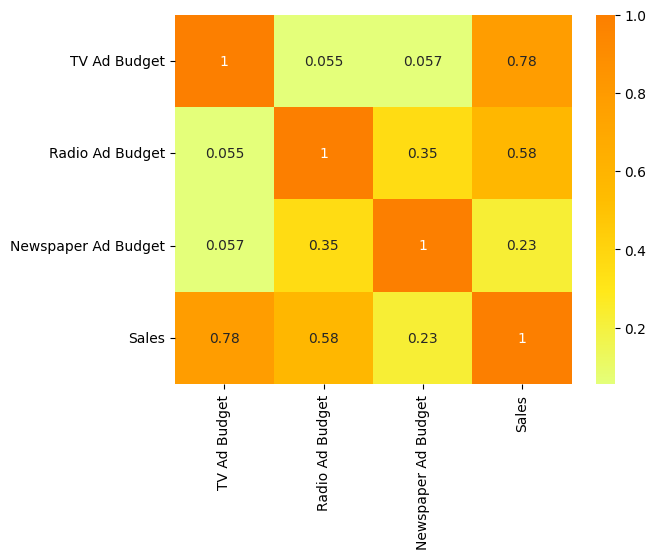

In [4]:
# Heatmap of correlations
sns.heatmap(data.corr(), cmap= 'Wistia', annot= True)
plt.show

- Observation:
    - High Correlation between Tv ads Budget and Sales;
    - Medium Correlation between Radio ads Budget and Sales;
    - Low Correlation between Newspaper ads Budget and Sales

#### Machine Learning Model

- Separating into training data and test data.

In [5]:
# Define features (X) and target variable (y)

y = data['Sales']
X = data.drop('Sales', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#### We have a regression problem - Let's choose the models we are going to use:

- Linear Regression
- RandomForest (Decision Tree)

In [6]:
# Create regression models
linear_model = LinearRegression()
random_forest_model = RandomForestRegressor()

# training the AI
linear_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

RandomForestRegressor()

#### Testing the AI e choosing the best model.

- We're going to use the R² -> Tells us % that our model can explain what happens

In [7]:
# Make predictions
linear_predictions = linear_model.predict(X_test)
rf_predictions = random_forest_model.predict(X_test)

# Evaluate the models
print("R^2 Score (Linear Regression):", metrics.r2_score(y_test, linear_predictions))
print("R^2 Score (Random Forest):", metrics.r2_score(y_test, rf_predictions)) 

R^2 Score (Linear Regression): 0.8609466508230368
R^2 Score (Random Forest): 0.982868893010429


#### Graphic View of Forecasts

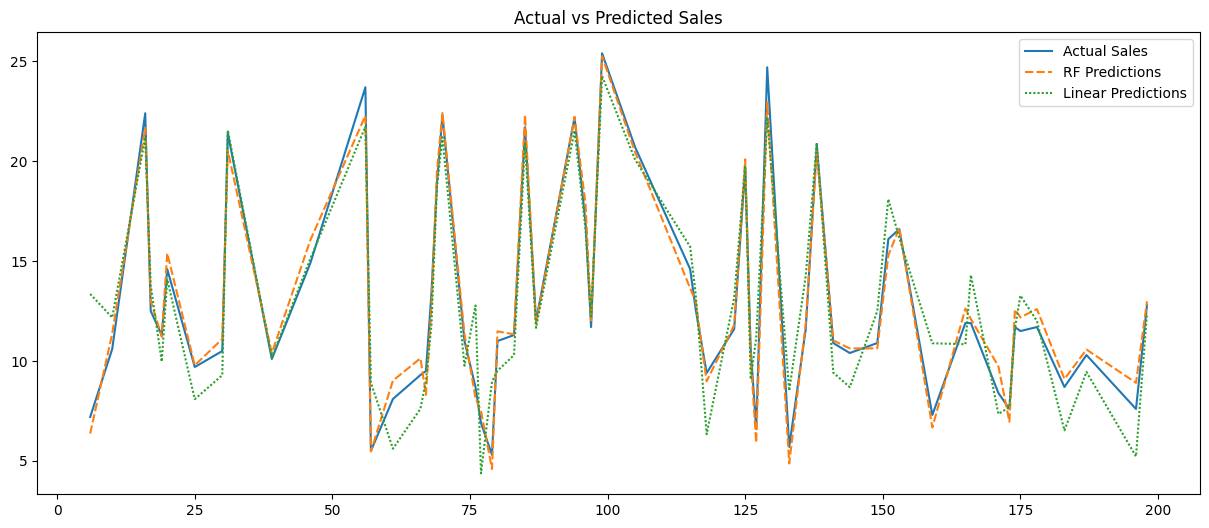

In [8]:
# Create a comparison DataFrame for predictions
comparison_df = pd.DataFrame()
comparison_df["Actual Sales"] = y_test
comparison_df["RF Predictions"] = rf_predictions
comparison_df["Linear Predictions"] = linear_predictions

# Visualize the predictions
plt.figure(figsize=(15, 6))
sns.lineplot(data=comparison_df)
plt.title('Actual vs Predicted Sales')
plt.show()

#### Comparative Chart

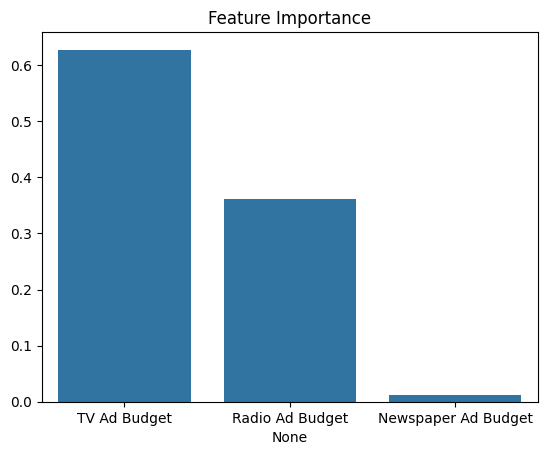

In [9]:
# Feature importance for Random Forest model
sns.barplot(x=X.columns, y=random_forest_model.feature_importances_)
plt.title('Feature Importance')
plt.show()

# Adding a New Feature

In [10]:
# Load the dataset
data = pd.read_csv('../data/advertising_budget_and_sales.csv', index_col=0)

In [11]:
# Create 'Internet Ad Budget' as the average of 'TV Ad Budget' and 'Radio Ad Budget'
data['Internet Ad Budget ($)'] = (data['TV Ad Budget ($)'] + data['Radio Ad Budget ($)']) / 2

# Reorganizing columns to put 'Internet Ad Budget ($)' before 'Sales ($)'
data = data[['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)', 'Internet Ad Budget ($)', 'Sales ($)']]

# Optionally rename columns
data.columns = ['TV Ad Budget', 'Radio Ad Budget', 'Newspaper Ad Budget', 'Internet Ad Budget', 'Sales']

# Display the first few rows of the dataset
print(data.head())
print(data.columns)

   TV Ad Budget  Radio Ad Budget  Newspaper Ad Budget  Internet Ad Budget  \
1         230.1             37.8                 69.2              133.95   
2          44.5             39.3                 45.1               41.90   
3          17.2             45.9                 69.3               31.55   
4         151.5             41.3                 58.5               96.40   
5         180.8             10.8                 58.4               95.80   

   Sales  
1   22.1  
2   10.4  
3    9.3  
4   18.5  
5   12.9  
Index(['TV Ad Budget', 'Radio Ad Budget', 'Newspaper Ad Budget',
       'Internet Ad Budget', 'Sales'],
      dtype='object')


In [12]:
# Define an impact factor for the Internet
impact_factor = 0.1  # por exemplo, cada dólar investido em Internet aumenta as vendas em $0.5

# Calculate new sales based on the Internet ad budget
data['Adjusted Sales'] = data['Sales'] + (data['Internet Ad Budget'] * impact_factor)

In [13]:
# Drop the original 'Sales' column to avoid confusion in the analysis
data = data.drop('Sales', axis=1)

In [14]:
# Visualizando as novas vendas
print(data[['Internet Ad Budget', 'Adjusted Sales']].head(10))

# Excluindo a coluna 'Sales' do DataFrame para manter a organização
#if 'Sales' in data.columns:
    #data = data.drop('Sales', axis=1)

    Internet Ad Budget  Adjusted Sales
1               133.95          35.495
2                41.90          14.590
3                31.55          12.455
4                96.40          28.140
5                95.80          22.480
6                28.80          10.080
7                45.15          16.315
8                69.90          20.190
9                 5.35           5.335
10              101.20          20.720


In [15]:
# Define features (X) and target variable (y)
y = data['Adjusted Sales']
X = data.drop('Adjusted Sales', axis=1)

In [16]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
# Creating the models
linear_model = LinearRegression()
random_forest_model = RandomForestRegressor()

# Training the models
linear_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

RandomForestRegressor()

In [18]:
# Making predictions
predictions_linear = linear_model.predict(X_test)
predictions_random_forest = random_forest_model.predict(X_test)

In [19]:
# Evaluating the models
print("R^2 Score (Linear Regression):", metrics.r2_score(y_test, predictions_linear))
print("R^2 Score (Random Forest):", metrics.r2_score(y_test, predictions_random_forest))

R^2 Score (Linear Regression): 0.9566459358700672
R^2 Score (Random Forest): 0.9883749550121006


In [20]:
# Preparing the auxiliary DataFrame for visualization
auxiliary_table = pd.DataFrame()
auxiliary_table["Actual Sales"] = y_test
auxiliary_table["Adjusted Sales"] = data.loc[y_test.index, 'Adjusted Sales']  # Incluindo Adjusted Sales
auxiliary_table["Predictions (Random Forest)"] = predictions_random_forest
auxiliary_table["Predictions (Linear Regression)"] = predictions_linear

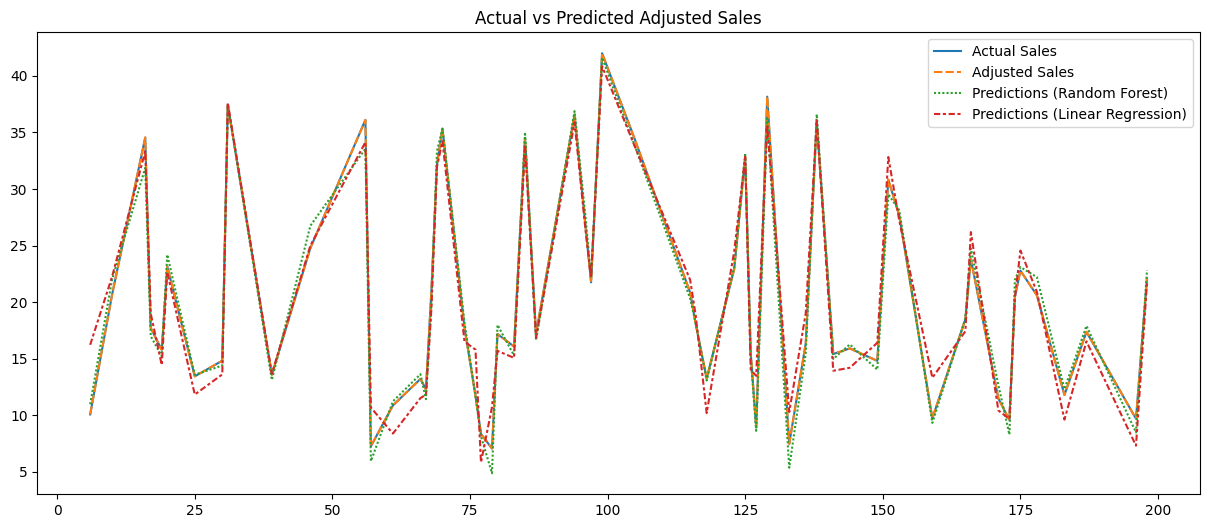

In [21]:
# Visualizing the predictions
plt.figure(figsize=(15, 6))
sns.lineplot(data=auxiliary_table)
plt.title('Actual vs Predicted Adjusted Sales')
plt.show()

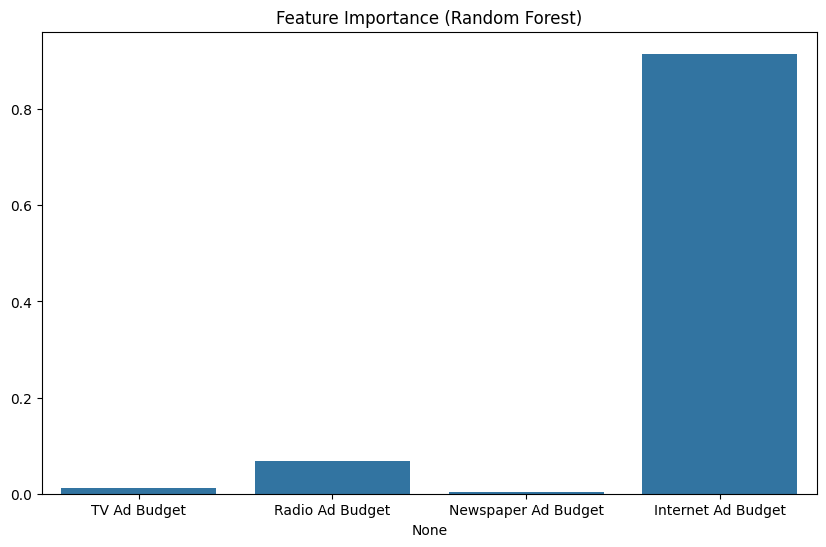

In [22]:
# Feature importance from Random Forest
plt.figure(figsize=(10, 6))
sns.barplot(x=X.columns, y=random_forest_model.feature_importances_)
plt.title('Feature Importance (Random Forest)')
plt.show()

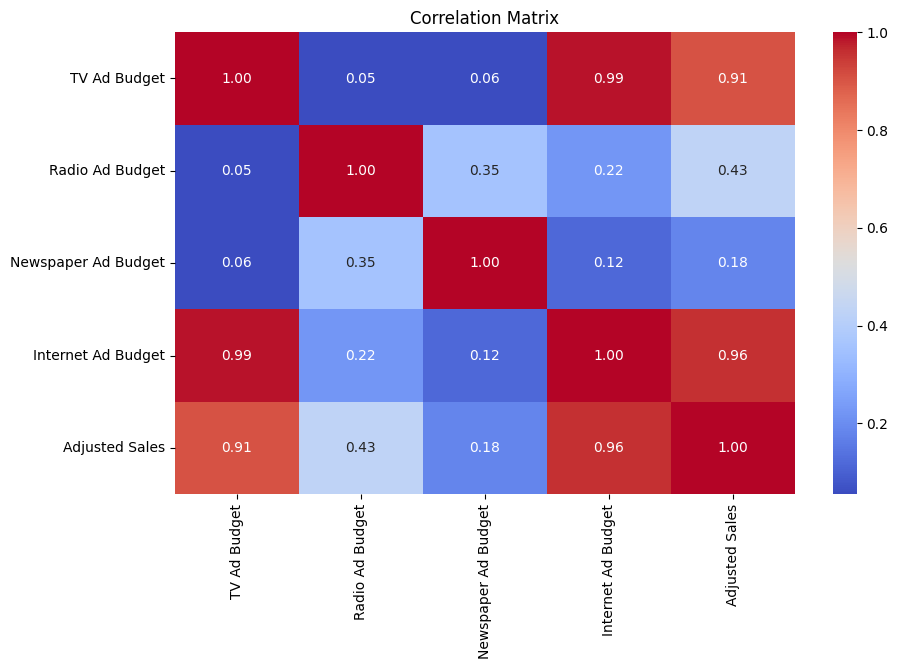

In [23]:

# Calculando a matriz de correlação
correlation_matrix = data.corr()

# Criando um heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

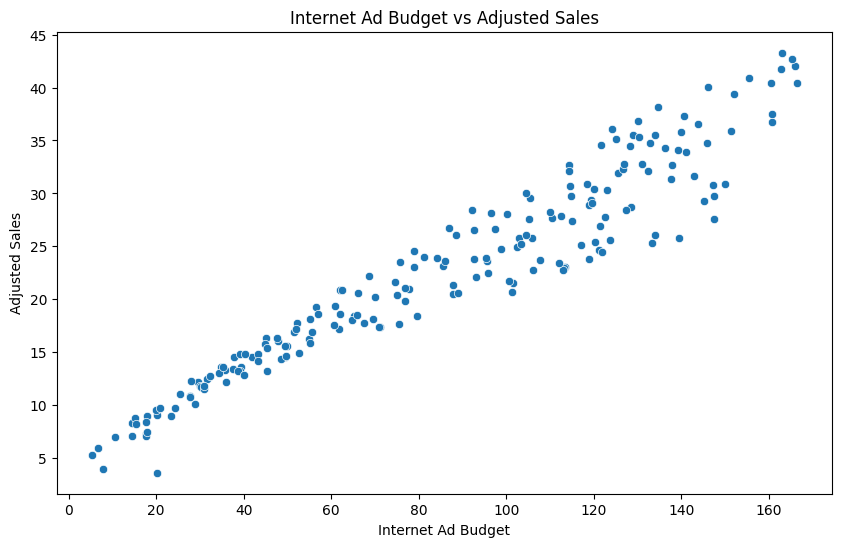

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Internet Ad Budget', y='Adjusted Sales')
plt.title('Internet Ad Budget vs Adjusted Sales')
plt.xlabel('Internet Ad Budget')
plt.ylabel('Adjusted Sales')
plt.show()

Linear Regression R² Score:
Training: 0.9697, Test: 0.9566
Cross-validation scores: [0.96373589 0.9733805  0.9784679  0.93867212 0.96856621]

Random Forest R² Score:
Training: 0.9981, Test: 0.9884
Cross-validation scores: [0.9890354  0.99117656 0.99067843 0.98065123 0.98204478]


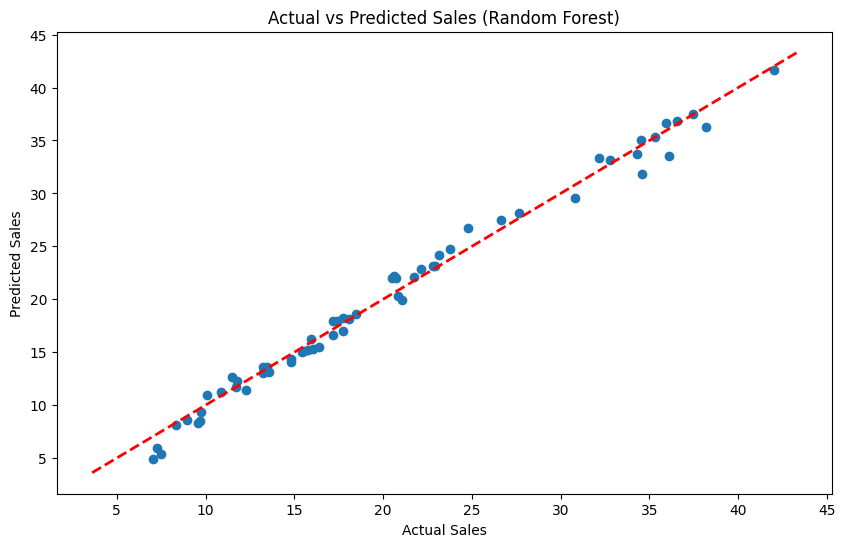

In [25]:


# Avaliando o desempenho do modelo de Linear Regression
linear_r2_train = linear_model.score(X_train, y_train)
linear_r2_test = linear_model.score(X_test, y_test)
linear_cv_scores = cross_val_score(linear_model, X, y, cv=5)

# Avaliando o desempenho do modelo de Random Forest
random_forest_r2_train = random_forest_model.score(X_train, y_train)
random_forest_r2_test = random_forest_model.score(X_test, y_test)
random_forest_cv_scores = cross_val_score(random_forest_model, X, y, cv=5)

# Resultados
print("Linear Regression R² Score:")
print(f"Training: {linear_r2_train:.4f}, Test: {linear_r2_test:.4f}")
print(f"Cross-validation scores: {linear_cv_scores}")

print("\nRandom Forest R² Score:")
print(f"Training: {random_forest_r2_train:.4f}, Test: {random_forest_r2_test:.4f}")
print(f"Cross-validation scores: {random_forest_cv_scores}")

# Visualizando Previsões vs Valores Reais para Random Forest
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions_random_forest)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (Random Forest)')
plt.show()